In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import os

In [2]:
#merge price datasets on date column
print(os.getcwd())
soy = pd.read_csv("../data/daily_soybean_prices.csv")
corn = pd.read_csv("../data/daily_corn_prices.csv")

# Keep only what we need
soy = soy[["Date", "Close"]].rename(columns={"Close": "soy_price"})
corn = corn[["Date", "Close"]].rename(columns={"Close": "corn_price"})

# Convert dates
soy["Date"] = pd.to_datetime(soy["Date"])
corn["Date"] = pd.to_datetime(corn["Date"])

# Merge on common trading dates
prices = pd.merge(soy, corn, on="Date", how="inner")

# Sort and drop missing values
prices = prices.sort_values("Date").dropna()

prices.head()

c:\Users\Antonio\Documents\Github\Spring2026-TIC\6_mean_reversion_strategy


,Date,soy_price,corn_price
1,2005-01-03,537.25,201.75
2,2005-01-04,529.75,201.0
3,2005-01-05,534.0,201.5
4,2005-01-06,541.75,208.75
5,2005-01-07,551.75,206.75


In [ ]:
# Clean price columns: remove commas and convert to numeric
prices["soy_price"] = (
    prices["soy_price"]
    .astype(str)
    .str.replace(",", "", regex=False)   # remove commas if they exist
    .str.strip()
)

prices["corn_price"] = (
    prices["corn_price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

prices["soy_price"] = pd.to_numeric(prices["soy_price"], errors="coerce")
prices["corn_price"] = pd.to_numeric(prices["corn_price"], errors="coerce")

In [ ]:
# Take log of prices to stabilize variance
prices["log_soy"] = np.log(prices["soy_price"])
prices["log_corn"] = np.log(prices["corn_price"])

In [9]:
print(soy.head())
print(corn.head())
print(prices.head())
print(prices.dtypes)

        Date soy_price
0        NaT      ZS=F
1 2005-01-03    537.25
2 2005-01-04    529.75
3 2005-01-05     534.0
4 2005-01-06    541.75
        Date corn_price
0        NaT       ZC=F
1 2005-01-03     201.75
2 2005-01-04      201.0
3 2005-01-05      201.5
4 2005-01-06     208.75
        Date  soy_price  corn_price   log_soy  log_corn
1 2005-01-03     537.25      201.75  6.286464  5.307029
2 2005-01-04     529.75      201.00  6.272405  5.303305
3 2005-01-05     534.00      201.50  6.280396  5.305789
4 2005-01-06     541.75      208.75  6.294805  5.341137
5 2005-01-07     551.75      206.75  6.313095  5.331510
Date          datetime64[us]
soy_price            float64
corn_price           float64
log_soy              float64
log_corn             float64
dtype: object


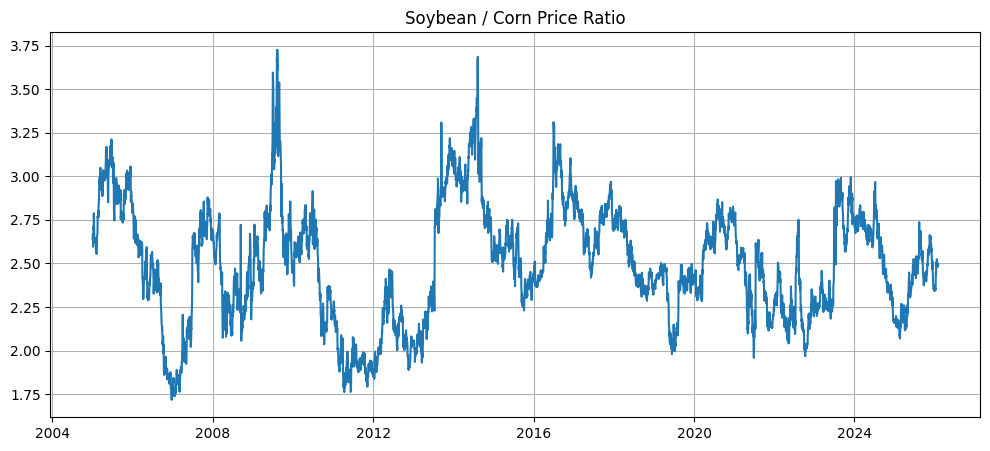

In [10]:
prices["ratio"] = prices["soy_price"] / prices["corn_price"]

plt.figure(figsize=(12,5))
plt.plot(prices["Date"], prices["ratio"])
plt.title("Soybean / Corn Price Ratio")
plt.grid(True)
plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(prices["ratio"])

print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical values:", adf_result[4])

ADF statistic: -3.792027722160257
p-value: 0.0029899431702200296
Critical values: {'1%': np.float64(-3.431590987642036), '5%': np.float64(-2.8620883885719604), '10%': np.float64(-2.567061906831349)}


In [13]:
import statsmodels.api as sm

X = sm.add_constant(prices["log_corn"])
model = sm.OLS(prices["log_soy"], X).fit()

beta = model.params["log_corn"]
print("beta =", beta)

prices["spread"] = prices["log_soy"] - beta * prices["log_corn"]

beta = 0.7629220658498728


In [14]:
adf = adfuller(prices["spread"])

print("ADF stat:", adf[0])
print("p-value:", adf[1])

ADF stat: -3.784187930595852
p-value: 0.0030733000766256834
